# **1. Perkenalan Dataset**


Data yang digunakan pada tugas ini adalah data penjualan toko online yang berasal dari Inggris dalam rentang tahun 2010-2011. Sumber data ini dari UCI, data ini memiliki 8 kolom yang terdiri dari object (4), float (2), dan datetime (1).

# **2. Import Library**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# **3. Memuat Dataset**

In [7]:
df_excel = pd.read_excel('Online Retail.xlsx')
df_excel.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df_excel.to_csv('online_retail.csv', index=False)
df = pd.read_csv('online_retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# **4. Exploratory Data Analysis (EDA)**

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


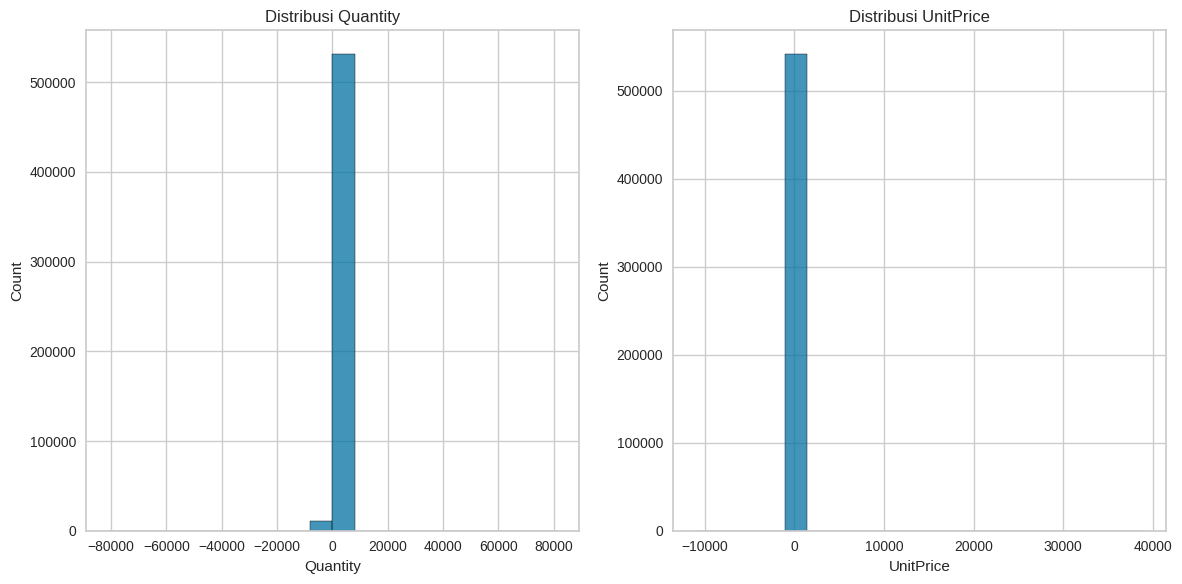

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(df['Quantity'], bins=20, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribusi Quantity')
axes[0].set_xlabel('Quantity')

sns.histplot(df['UnitPrice'], bins=20, ax=axes[1], edgecolor='black')
axes[1].set_title('Distribusi UnitPrice')
axes[1].set_xlabel('UnitPrice')

plt.tight_layout()
plt.show()

<ipython-input-5-490008a1a710>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts_filtered.index, y=country_counts_filtered.values, palette='rocket')


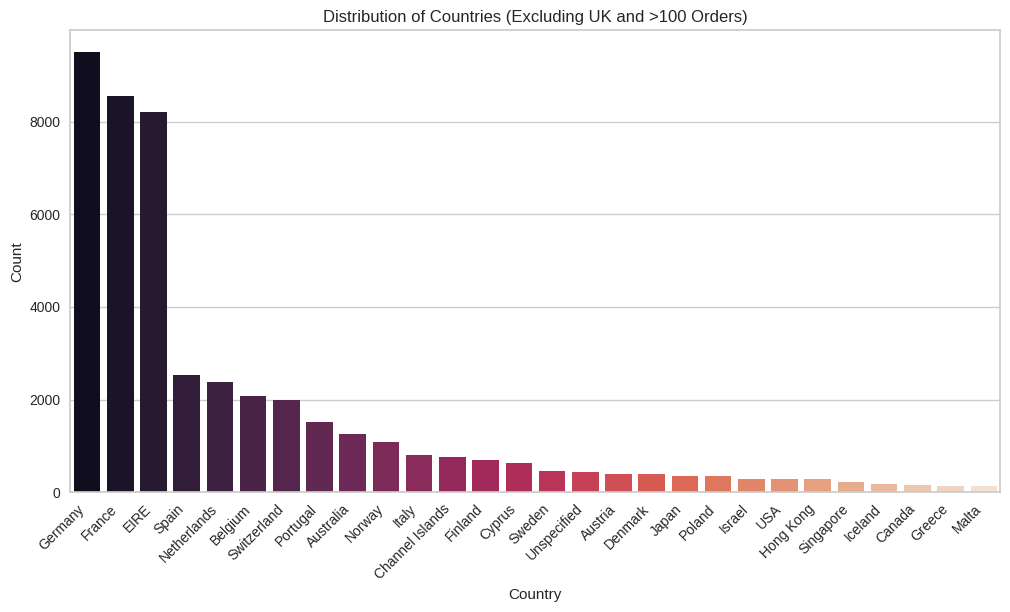

In [ ]:
country_counts = df['Country'].value_counts()
country_counts_filtered = country_counts[country_counts > 100]
country_counts_filtered = country_counts_filtered[country_counts_filtered.index != 'United Kingdom']

plt.figure(figsize=(12, 6))
#colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"
sns.barplot(x=country_counts_filtered.index, y=country_counts_filtered.values, palette='rocket')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Distribution of Countries (Excluding UK and >100 Orders)')

plt.show()

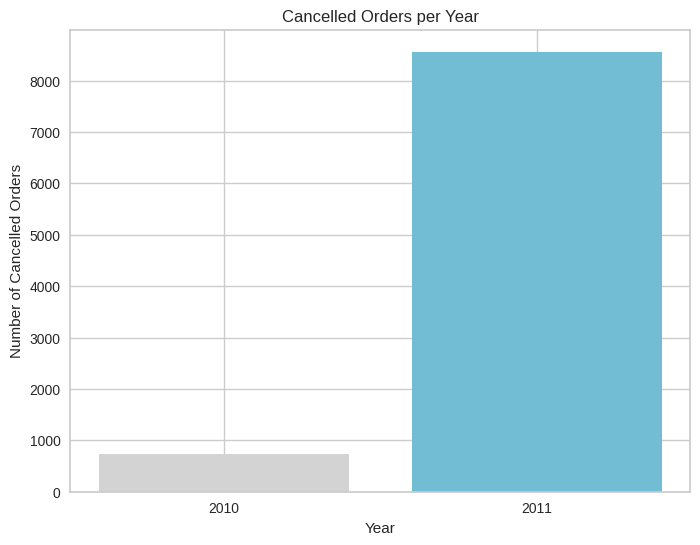

In [ ]:
df['Year'] = pd.to_datetime(df['InvoiceDate']).dt.year
cancelled_orders = df[df['InvoiceNo'].astype(str).str.startswith('C')]

cancelled_orders_by_year = cancelled_orders.groupby('Year')['InvoiceNo'].count()
cancelled_orders_by_year.index = cancelled_orders_by_year.index.astype(int)

plt.figure(figsize=(8,6))
color = ["#D3D3D3", "#72BCD4"]
plt.bar(cancelled_orders_by_year.index, cancelled_orders_by_year.values, color=color)
plt.xlabel('Year')
plt.ylabel('Number of Cancelled Orders')
plt.title('Cancelled Orders per Year')
plt.xticks([2010, 2011])
plt.show()

# **5. Data Preprocessing**

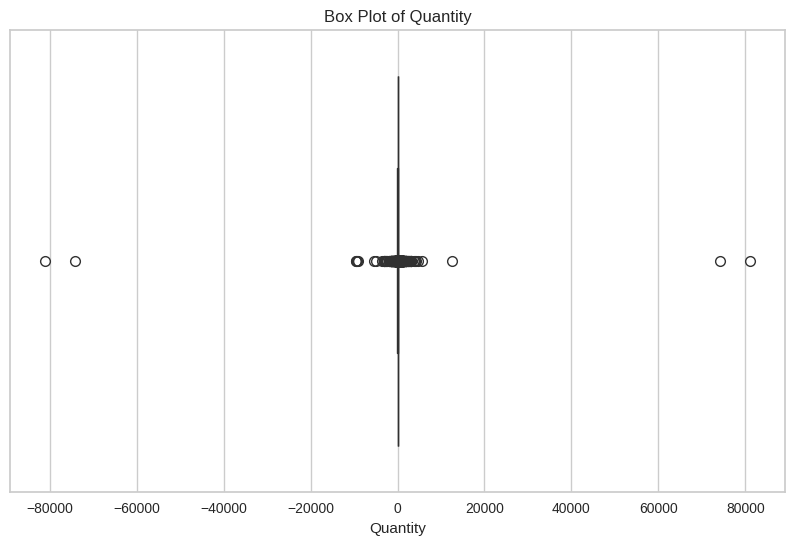

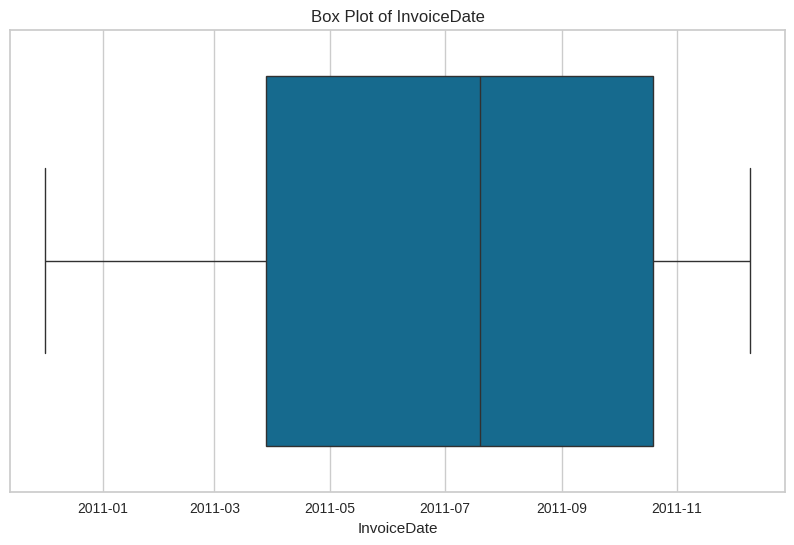

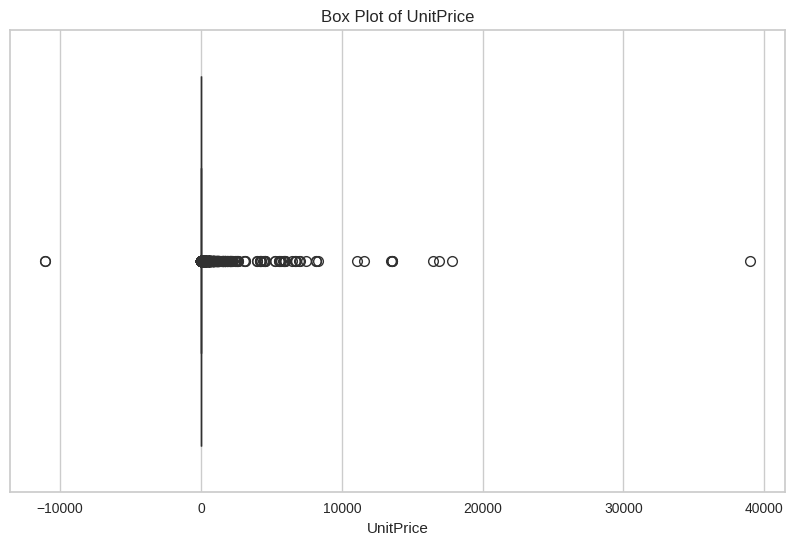

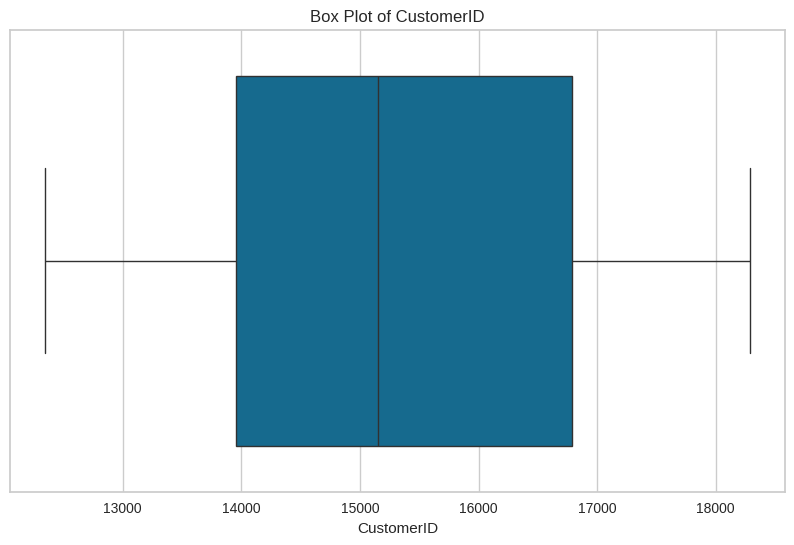

In [ ]:
for feature in df.select_dtypes(exclude='object').columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

In [ ]:
count_negative = (df['Quantity'] < 0).sum()
print(f'Jumlah Quantity yang negatif: {count_negative}')

count_negative = (df['UnitPrice'] < 0).sum()
print(f'Jumlah UnitPrice yang negatif: {count_negative}')

Jumlah Quantity yang negatif: 10624
Jumlah UnitPrice yang negatif: 2


In [ ]:
outlier_df = df[['Quantity', 'UnitPrice']]
Q1 = outlier_df.quantile(0.25)
Q3 = outlier_df.quantile(0.75)
IQR = Q3 - Q1

condition = ~((outlier_df < (Q1 - 1.5 * IQR)) | (outlier_df > (Q3 + 1.5 * IQR))).any(axis=1)
df = df[condition]

In [ ]:
count_negative_after = (df['Quantity'] < 0).sum()
print(f'Jumlah Quantity yang negatif setelah dihapus: {count_negative_after}')

count_negative_after = (df['UnitPrice'] < 0).sum()
print(f'Jumlah UnitPrice yang negatif setelah dihapus: {count_negative_after}')

Jumlah Quantity yang negatif setelah dihapus: 7035
Jumlah UnitPrice yang negatif setelah dihapus: 0


In [ ]:
df = df.dropna(subset=['CustomerID', 'Description'])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C', na=False)]

In [ ]:
count_negative_after_drop = (df['Quantity'] < 0).sum()
print(f'Jumlah Quantity yang negatif setelah dihapus: {count_negative_after_drop}')

count_negative_after_drop = (df['UnitPrice'] < 0).sum()
print(f'Jumlah UnitPrice yang negatif setelah dihapus: {count_negative_after_drop}')

Jumlah Quantity yang negatif setelah dihapus: 0
Jumlah UnitPrice yang negatif setelah dihapus: 0


In [ ]:
# Log transform karena jika dilihat dari boxplot data Quantity dan UntiPrice memeiliki distribusi right-skewness
df['Quantity'] = np.log1p(df['Quantity'])
df['UnitPrice'] = np.log1p(df['UnitPrice'])

<ipython-input-5-1bd0dae24a71>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Quantity'] = np.log1p(df['Quantity'])
<ipython-input-5-1bd0dae24a71>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['UnitPrice'] = np.log1p(df['UnitPrice'])


In [ ]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
cust_data = df.groupby('CustomerID').agg({
    'TotalAmount': 'sum',
    'InvoiceNo': 'count',
    'InvoiceDate': lambda x: (pd.to_datetime(x.max()) - pd.to_datetime(x.max())).days,
    'Quantity': 'sum',
    'Country': 'first'
}).rename(columns={'InvoiceNo': 'Frequency of Purchase', 'InvoiceDate': 'Recency', 'Quantity': 'Number of Item'})
cust_data.head()

<ipython-input-6-4a093704b384>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TotalAmount'] = df['Quantity'] * df['UnitPrice']


,TotalAmount,Frequency of Purchase,Recency,Number of Item,Country
CustomerID,,,,,
12347.0,363.543570,141,0,313.716495,Iceland
12348.0,1.872946,1,0,3.044522,Finland
12349.0,154.265754,61,0,125.895126,Italy
12350.0,35.451643,15,0,37.688147,Norway
12352.0,165.476234,67,0,134.481200,Norway


In [ ]:
cust_data['Encoded_Country'] = cust_data.groupby('Country')['TotalAmount'].transform('mean') # Mengencode Country berdasarkan rata-rata total amount
cust_data.head()

,TotalAmount,Frequency of Purchase,Recency,Number of Item,Country,Encoded_Country
CustomerID,,,,,,
12347.0,363.543570,141,0,313.716495,Iceland,363.543570
12348.0,1.872946,1,0,3.044522,Finland,98.321110
12349.0,154.265754,61,0,125.895126,Italy,108.021424
12350.0,35.451643,15,0,37.688147,Norway,171.111822
12352.0,165.476234,67,0,134.481200,Norway,171.111822


In [ ]:
cust_data.drop(columns=['Country'], inplace=True) # Drop kolom country
cust_data.head()

,TotalAmount,Frequency of Purchase,Recency,Number of Item,Encoded_Country
CustomerID,,,,,
12347.0,363.543570,141,0,313.716495,363.543570
12348.0,1.872946,1,0,3.044522,98.321110
12349.0,154.265754,61,0,125.895126,108.021424
12350.0,35.451643,15,0,37.688147,171.111822
12352.0,165.476234,67,0,134.481200,171.111822


In [ ]:
scale = StandardScaler()
cust_data_scaled = scale.fit_transform(cust_data[['TotalAmount', 'Frequency of Purchase', 'Recency', 'Number of Item', 'Encoded_Country']])

# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

In [ ]:
kmenans = KMeans()
kmenans.fit(cust_data_scaled)

KMeans()

## **b. Evaluasi Model Clustering**

In [ ]:
kmeans_scores = silhouette_score(cust_data_scaled, kmenans.labels_) # Silhouette Score sebelum meenentukan jumlah cluster
print(kmeans_scores)

0.6163671266367304


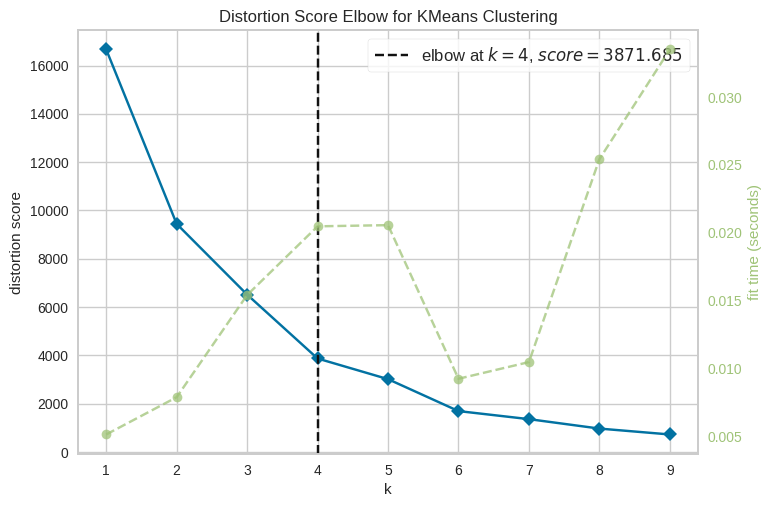

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
kmeans = KMeans()
Visualizer = KElbowVisualizer(kmeans, k=(1,10))
Visualizer.fit(cust_data_scaled)
Visualizer.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(cust_data_scaled)

KMeans(n_clusters=4, random_state=42)

In [ ]:
score = silhouette_score(cust_data_scaled, kmeans.labels_)
print(score)

0.7896939577803128


## **c. Feature Selection (Opsional)**

In [ ]:
feature_selections = cust_data[['TotalAmount', 'Frequency of Purchase', 'Recency']]

scale = StandardScaler()
feature_selections_scaled = scale.fit_transform(feature_selections)

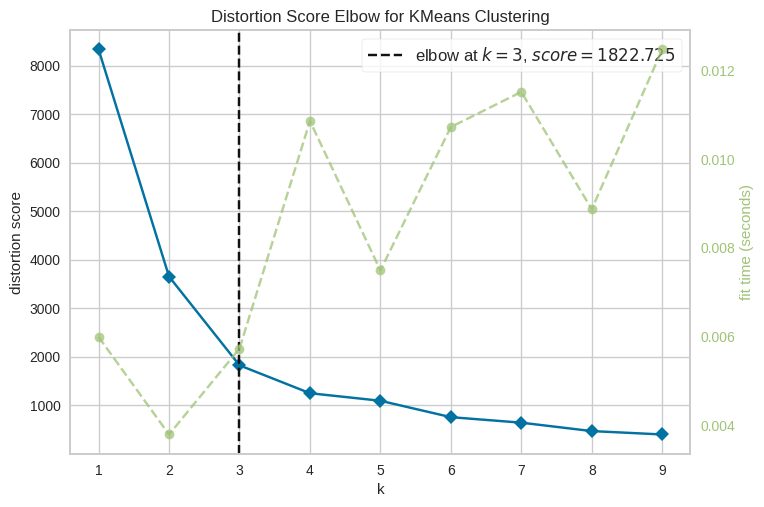

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
kmeans_feature_selections = KMeans()
Visualizer = KElbowVisualizer(kmeans_feature_selections, k=(1,10))
Visualizer.fit(feature_selections_scaled)
Visualizer.show()

In [ ]:
kmeans_feature_selections = KMeans(n_clusters=3, random_state=42)
kmeans_feature_selections.fit(feature_selections_scaled)

KMeans(n_clusters=3, random_state=42)

In [ ]:
score = silhouette_score(feature_selections_scaled, kmeans_feature_selections.labels_)
print(score)

0.7910798642078261


Pada model yang tidak melakukan feature selection memiliki silhoutte score sebesar 0.78, saat melakukan feature selection model memiliki silhouette score sebesar 0.79. Berdasarkan hasil yang didapat dari silhouette model yang menggunakan feature selection memiliki kinerja lebih baik.

## **d. Visualisasi Hasil Clustering**

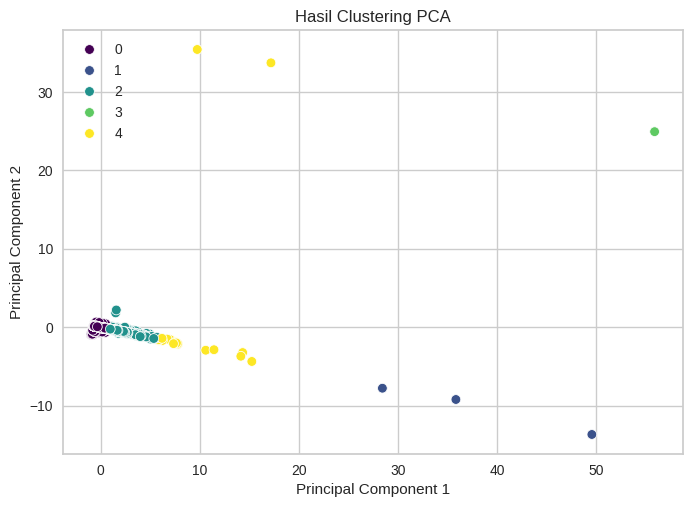

In [ ]:
# Visualisasi hasil clustering sebelum melakuakn feature selection
pca = PCA(n_components=2)
cust_data_scaled_pca = pca.fit_transform(cust_data_scaled)

sns.scatterplot(x=cust_data_scaled_pca[:, 0], y=cust_data_scaled_pca[:, 1], hue=kmeans.labels_, palette='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Hasil Clustering PCA')
plt.show()

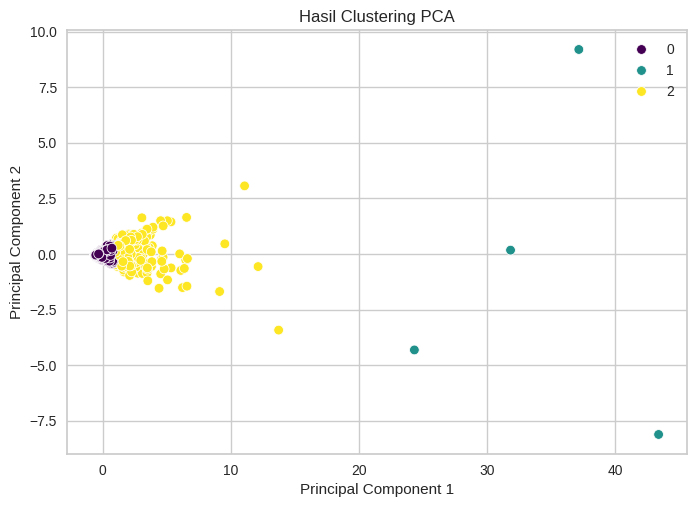

In [ ]:
# Visualisasi hasil clustering setelah melakukan feature selection
pca = PCA(n_components=2)
feature_selections_pca = pca.fit_transform(feature_selections_scaled)

sns.scatterplot(x=feature_selections_pca[:, 0], y=feature_selections_pca[:, 1], hue=kmeans_feature_selections.labels_, palette='viridis')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Hasil Clustering PCA')
plt.show()

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

In [ ]:
cust_data['Cluster'] = kmeans_feature_selections.labels_
cust_data.head()

,TotalAmount,Frequency of Purchase,Recency,Number of Item,Encoded_Country,Cluster
CustomerID,,,,,,
12347.0,363.543570,141,0,313.716495,363.543570,0
12348.0,1.872946,1,0,3.044522,98.321110,0
12349.0,154.265754,61,0,125.895126,108.021424,0
12350.0,35.451643,15,0,37.688147,171.111822,0
12352.0,165.476234,67,0,134.481200,171.111822,0


In [ ]:
df['Quantity'] = np.expm1(df['Quantity'])
df['UnitPrice'] = np.expm1(df['UnitPrice'])

df = df.merge(cust_data[['Cluster']], left_on='CustomerID', right_index=True)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2.465366,2
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2.878642,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2.904194,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2.878642,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2.878642,2


In [ ]:
analysis_cluster = df.groupby('Cluster').agg({
    'InvoiceNo': 'count',
    'TotalAmount': 'sum'
}).rename(columns={'InvoiceNo': 'Frequency of Purchase', 'TotalAmount': 'Total Spending'})

analysis_cluster

,Frequency of Purchase,Total Spending
Cluster,,
0,178022,341114.256259
1,20241,29001.053423
2,122772,210104.278793


Tulis hasil interpretasinya di sini.
1. Cluster 0: Frekuensi belanja tinggi dan mengeluarkan banyak uang
2. Cluster 1: Frekuensi belanja rendah dan mengeluarkan sedikit uang
3. Cluster 2: Diantara dua cluster sebelumnya

# Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

## Cluster 0:
- **Rata-rata Frekuensi Belanja: 178022
- **Rata-rata Spending: 341114.25
- **Analisis:** Cluster ini mencakup pelanggan dengan frekuensi belanja yang tinggi dan tingkat pengeluarkan yang tinggi. Pelanggan dalam cluster ini memiliki daya beli yang kuat dan cenderung mengeluarkan uang dalam jumlah besar.

## Cluster 1:
- **Rata-rata Frekuensi Belanja: 20241
- **Rata-rata Spending: 29001.05
- **Analisis:** Cluster ini menunjukkan pelanggan dengan frekuensi belanja yang tidak terlalu tinggi dan tingkat pengeluaran yang tidak terlalu tinggi juga, Pelanggan dalam cluster ini cenderung memiliki daya beli yang kurang kuat dan cenderung mengeluaran uang dalam jumlah tidak terlalu besar.

## Cluster 2:
- **Rata-rata Frekuensi Belanja: 122772
- **Rata-rata Spending: 210104.27
- **Analisis:** Cluster ini terdiri dari pelanggan dengan frekuensi belanja dan tingkat pengeluaran yang menenang diantara kedua cluster sebelumnya. Pelanggan dalam cluster ini mungkin memiliki daya beli yang cukup besar dan akan mengeluarkan uang yang cukup besar untuk barang yang sedang diperlukan saja.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [ ]:
df.to_csv('online_retail_clustering.csv', index=False)

In [ ]:
df = pd.read_csv('online_retail_clustering.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2.465366,2
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2.878642,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2.904194,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2.878642,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2.878642,2
